# **Employee Turnover Prediction: Data-Driven Insights for HR**



## Project Overview

This project analyzes employee data from Salifort Motors to identify factors associated with employee turnover and build a machine learning model that predicts whether an employee is likely to leave the company.

The project uses exploratory data analysis, data preprocessing, and a Random Forest classification model to investigate employee turnover and identify the features that contribute most to the model's predictions.

The goal is to provide HR stakeholders with data-driven insights that can help them better understand employee turnover and support employee retention efforts.



# **PACE stages**
The project followed the PACE framework—Plan, Analyze, Construct, and Execute—to structure the analysis and development of the employee turnover prediction model.

### Understand the business scenario and problem

The HR department at Salifort Motors wants to take some initiatives to improve employee satisfaction levels at the company. They collected data from employees, but now they don’t know what to do with it. They refer to you as a data analytics professional and ask you to provide data-driven suggestions based on your understanding of the data. They have the following question: what’s likely to make the employee leave the company?

Your goals in this project are to analyze the data collected by the HR department and to build a model that predicts whether or not an employee will leave the company.

If you can predict employees likely to quit, it might be possible to identify factors that contribute to their leaving. Because it is time-consuming and expensive to find, interview, and hire new employees, increasing employee retention will be beneficial to the company.

### Familiarize yourself with the HR dataset

The dataset that you'll be using in this lab contains 15,000 rows and 10 columns for the variables listed below. 

**Note:** you don't need to download any data to complete this lab. For more information about the data, refer to its source on [Kaggle](https://www.kaggle.com/datasets/mfaisalqureshi/hr-analytics-and-job-prediction?select=HR_comma_sep.csv).

Variable  |Description |
-----|-----|
satisfaction_level|Employee-reported job satisfaction level [0&ndash;1]|
last_evaluation|Score of employee's last performance review [0&ndash;1]|
number_project|Number of projects employee contributes to|
average_monthly_hours|Average number of hours employee worked per month|
time_spend_company|How long the employee has been with the company (years)
Work_accident|Whether or not the employee experienced an accident while at work
left|Whether or not the employee left the company
promotion_last_5years|Whether or not the employee was promoted in the last 5 years
Department|The employee's department
salary|The employee's salary (U.S. dollars)

## Step 1. Imports

*   Import packages
*   Load dataset



### Import packages

In [5]:
# Import packages

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score,\
f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

### Load dataset



In [7]:
# RUN THIS CELL TO IMPORT YOUR DATA. 

# Load dataset into a dataframe
df0 = pd.read_csv("HR_capstone_dataset.csv")


# Display first few rows of the dataframe
df0.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


## Step 2. Data Exploration (Initial EDA and data cleaning)

- Understand your variables
- Clean your dataset (missing data, redundant data, outliers)



### Gather basic information about the data

In [ ]:
# Gather basic information about the data
df0.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


### Gather descriptive statistics about the data

In [8]:
# Gather descriptive statistics about the data
df0.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


### Rename columns

In [9]:
# Display all column names

df0.dtypes

satisfaction_level       float64
last_evaluation          float64
number_project             int64
average_montly_hours       int64
time_spend_company         int64
Work_accident              int64
left                       int64
promotion_last_5years      int64
Department                   str
salary                       str
dtype: object

In [10]:
# Rename columns as needed


df0 = df0.rename(
    columns={
        "average_montly_hours": "average_monthly_hours",
        "time_spend_company": "time_spent_company",
        "Work_accident": "work_accident",
        "Department": "department",
    }
)

# Ensure all column names are lowercase

df0.columns = df0.columns.str.lower()

# Display all column names after the update

df0.head()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,time_spent_company,work_accident,left,promotion_last_5years,department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


### Check missing values

Check for any missing values in the data.

In [11]:
# Check for missing values

df0.isna().sum()

satisfaction_level       0
last_evaluation          0
number_project           0
average_monthly_hours    0
time_spent_company       0
work_accident            0
left                     0
promotion_last_5years    0
department               0
salary                   0
dtype: int64

### Check duplicates

Check for any duplicate entries in the data.

In [12]:
# Check for duplicates

df0.duplicated().sum()

np.int64(3008)

In [13]:
# Inspect some rows containing duplicates as needed

df0[df0.duplicated(keep=False)]

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,time_spent_company,work_accident,left,promotion_last_5years,department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low
...,...,...,...,...,...,...,...,...,...,...
14994,0.40,0.57,2,151,3,0,1,0,support,low
14995,0.37,0.48,2,160,3,0,1,0,support,low
14996,0.37,0.53,2,143,3,0,1,0,support,low
14997,0.11,0.96,6,280,4,0,1,0,support,low


In [14]:
# Drop duplicates and save resulting dataframe in a new variable as needed

df1 = df0.drop_duplicates()

# Display first few rows of new dataframe as needed

df1.head()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,time_spent_company,work_accident,left,promotion_last_5years,department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


### Check outliers

Check for outliers in the data.

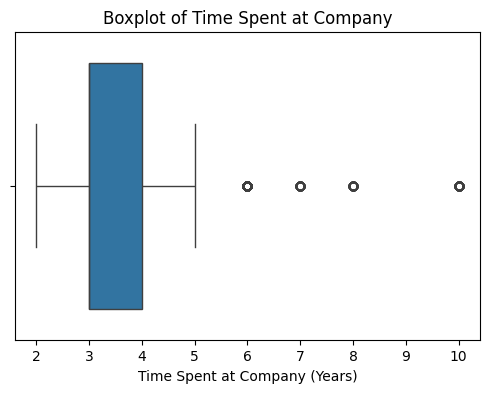

In [32]:
# Create a boxplot to visualize distribution of `time_spend_company` and detect any outliers


plt.figure(figsize=(6, 4))
sns.boxplot(data=df1, x="time_spent_company")
plt.title("Boxplot of Time Spent at Company")
plt.xlabel("Time Spent at Company (Years)")

plt.savefig('images/time_spent_company_turnover.png', bbox_inches='tight', dpi=100)
plt.show()

In [16]:
# Determine the number of rows containing outliers


# Calculate IQR for time_spent_company
percentile25 = df1["time_spent_company"].quantile(0.25)
percentile75 = df1["time_spent_company"].quantile(0.75)
iqr = percentile75 - percentile25

# Define upper and lower bounds
upper_limit = percentile75 + 1.5 * iqr
lower_limit = percentile25 - 1.5 * iqr
print("Lower limit:", lower_limit)
print("Upper limit:", upper_limit)

# Identify outliers
outliers = df1[
    (df1["time_spent_company"] > upper_limit)
    | (df1["time_spent_company"] < lower_limit)
]

# Count the number of outlier rows
print("Number of rows containing outliers:", len(outliers))

Lower limit: 1.5
Upper limit: 5.5
Number of rows containing outliers: 824


# pAce: Analyze Stage
- Perform EDA (analyze relationships between variables)



## Step 2. Data Exploration (Continue EDA)

Begin by understanding how many employees left and what percentage of all employees this figure represents.

In [17]:
# Get numbers of people who left vs. stayed


stayed = df1[df1['left'] == 0]
left = df1[df1['left'] == 1]

print('People who stayed:', len(stayed))
print('People who left:', len(left))

# Get percentages of people who left vs. stayed


percentages = df1['left'].value_counts(normalize=True) * 100

print(f"Percentage who stayed: {percentages[0]:.2f}%")
print(f"Percentage who left: {percentages[1]:.2f}%")

People who stayed: 10000
People who left: 1991
Percentage who stayed: 83.40%
Percentage who left: 16.60%


### Data visualizations

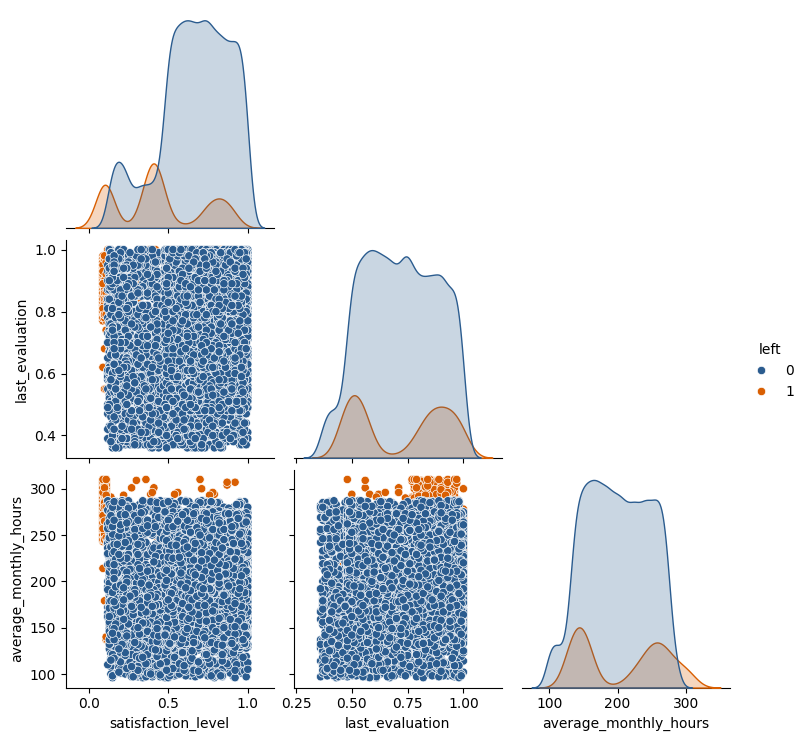

In [18]:
# Create a plot as needed


# Select only 3 main features + target variable 'left'
sns.pairplot(
    data=df1[['satisfaction_level', 'last_evaluation', 'average_monthly_hours', 'left']], 
    hue='left', 
    palette={0: '#2b5c8f', 1: '#d95f02'},
    corner=True
)
plt.savefig('images/satisfaction_turnover.png', bbox_inches='tight', dpi=300)
plt.show()

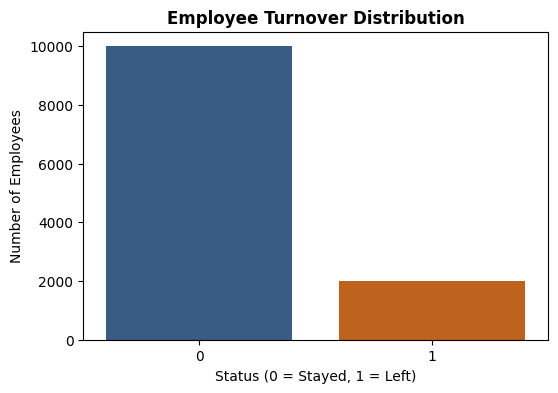

In [34]:
# Create Employee Turnover Distribution plot
plt.figure(figsize=(6, 4))
sns.countplot(
    data=df1, 
    x='left', 
    hue='left', 
    palette={0: '#2b5c8f', 1: '#d95f02'}, 
    legend=False
)
plt.title('Employee Turnover Distribution', fontsize=12, fontweight='bold')
plt.xlabel('Status (0 = Stayed, 1 = Left)', fontsize=10)
plt.ylabel('Number of Employees', fontsize=10)

plt.savefig('images/turnover_distribution.png', bbox_inches='tight', dpi=100)
plt.show()

C:\Users\96659\AppData\Local\Temp\ipykernel_17544\1742953109.py:22: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


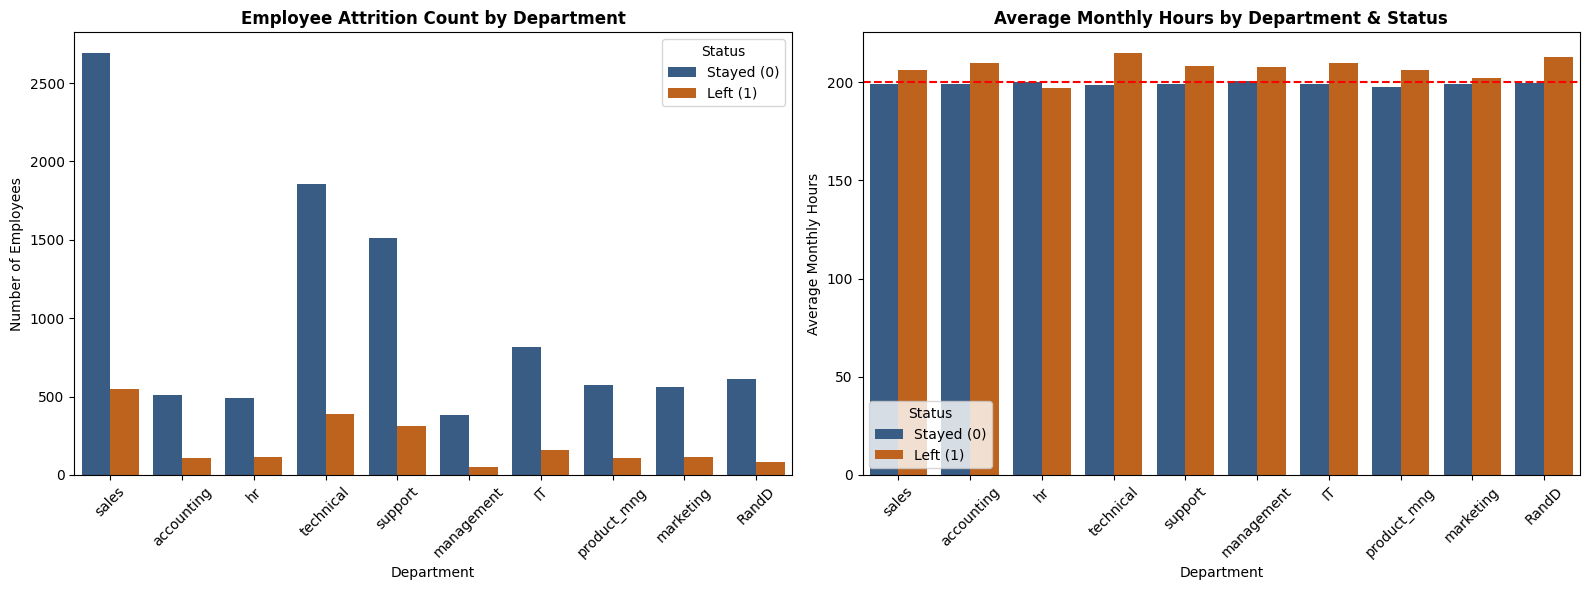

In [30]:
# Create a plot as needed


# Set up canvas with 2 subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Employee Turnover Count by Department
sns.countplot(
    data=df1, 
    x='department', 
    hue='left', 
    palette={0: '#2b5c8f', 1: '#d95f02'}, 
    ax=axes[0]
)
axes[0].set_title('Employee Attrition Count by Department', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Department', fontsize=10)
axes[0].set_ylabel('Number of Employees', fontsize=10)
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(title='Status', labels=['Stayed (0)', 'Left (1)'])

# Plot 2: Average Monthly Hours vs. Department by Attrition (Burnout Check)
sns.barplot(
    data=df1, 
    x='department', 
    y='average_monthly_hours', 
    hue='left', 
    palette={0: '#2b5c8f', 1: '#d95f02'}, 
    ci=None, 
    ax=axes[1]
)
axes[1].set_title('Average Monthly Hours by Department & Status', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Department', fontsize=10)
axes[1].set_ylabel('Average Monthly Hours', fontsize=10)
axes[1].tick_params(axis='x', rotation=45)
axes[1].axhline(200, color='red', linestyle='--', label='200 HR Threshold')
axes[1].legend(title='Status', labels=['Stayed (0)', 'Left (1)'])

plt.savefig('images/monthly_hours_turnover.png', bbox_inches='tight', dpi=100)
plt.tight_layout()
plt.show()

C:\Users\96659\AppData\Local\Temp\ipykernel_17544\2808778049.py:9: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
C:\Users\96659\AppData\Local\Temp\ipykernel_17544\2808778049.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


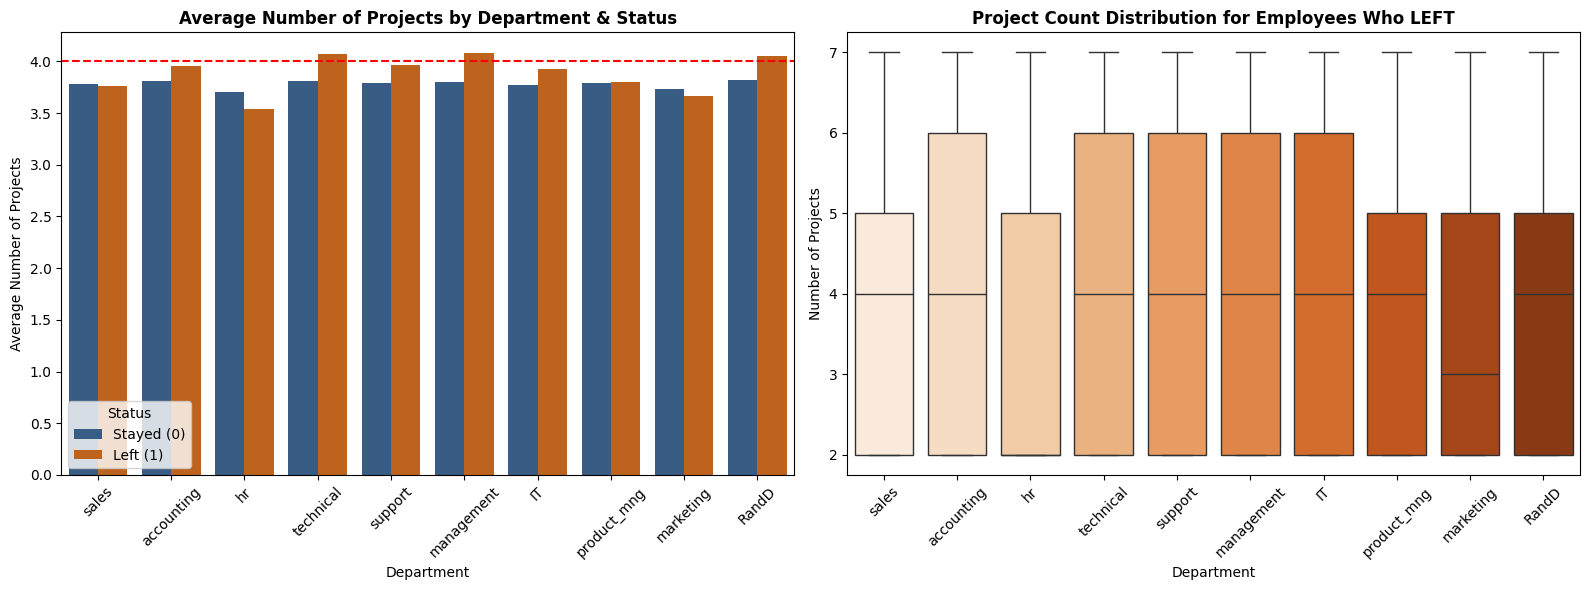

--- Average Projects per Department by Status ---
left                0         1
department                     
IT           3.771394  3.930380
RandD        3.822660  4.047059
accounting   3.808594  3.954128
hr           3.706967  3.539823
management   3.804688  4.076923
marketing    3.732620  3.660714
product_mng  3.793403  3.800000
sales        3.779844  3.763636
support      3.790590  3.967949
technical    3.814455  4.071795


In [ ]:
# Create a plot as needed


# Set up side-by-side plots for department project workload
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Average Number of Projects per Department by Attrition Status
sns.barplot(
    data=df1, 
    x='department', 
    y='number_project', 
    hue='left', 
    palette={0: '#2b5c8f', 1: '#d95f02'}, 
    ci=None, 
    ax=axes[0]
)
axes[0].set_title('Average Number of Projects by Department & Status', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Department', fontsize=10)
axes[0].set_ylabel('Average Number of Projects', fontsize=10)
axes[0].tick_params(axis='x', rotation=45)
axes[0].axhline(4.0, color='red', linestyle='--', label='Overwork Threshold (4+ Projects)')
axes[0].legend(title='Status', labels=['Stayed (0)', 'Left (1)'])

# Plot 2: Boxplot showing project distribution across departments for those who LEFT
sns.boxplot(
    data=df1[df1['left'] == 1], 
    x='department', 
    y='number_project', 
    palette='Oranges', 
    ax=axes[1]
)
axes[1].set_title('Project Count Distribution for Employees Who LEFT', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Department', fontsize=10)
axes[1].set_ylabel('Number of Projects', fontsize=10)
axes[1].tick_params(axis='x', rotation=45)

plt.savefig('images/projects_turnover.png', bbox_inches='tight', dpi=100)
plt.tight_layout()
plt.show()

# Print average projects per department by status
print("--- Average Projects per Department by Status ---")
print(df1.groupby(['department', 'left'])['number_project'].mean().unstack())

### Insights


### Key Findings & Insights

#### 1. Main Causes of Employee Turnover

* **Key Drivers:** Employee satisfaction level (`satisfaction_level`) and monthly working hours (`average_monthly_hours`) are the two primary factors deciding whether an employee stays or leaves.



#### 2. Why Employees Leave

* **Low Satisfaction:** Employees with low satisfaction scores ($0.1$ to $0.4$) have extremely high turnover rates.


* **Burnout from Long Hours:** Employees working $280$ to $300+$ hours per month leave due to severe burnout.


* **Two Main Groups Leave:** The data clearly splits departing employees into two groups: disengaged low-performers and overworked top-performers.



#### 3. Department Breakdown (Hours & Departures)

* **Highest Exit Counts:** **Sales**, **Technical**, and **Support** have the largest number of employees leaving, mainly due to having larger total team sizes.


* **Overtime Across All Teams:** In almost every department, employees who left consistently worked **over 200 hours per month**, which is significantly higher than those who stayed.



#### 4. Project Workload & Overworked Teams

* **Too Few or Too Many Projects:** Turnover is highest at two extremes: employees with only **2 projects** (underutilized) and those with **6–7 projects** (overloaded). Almost 100% of employees assigned to 7 projects left the company.


* **The Sweet Spot:** Employees assigned **3 to 5 projects** are the most stable and least likely to leave.


* **Most Overworked Departments:** **Technical**, **Management**, **R&D**, and **Accounting** assign the highest average number of projects to employees who end up leaving.

# paCe: Construct Stage



### Constructing Stage Reflection

* **Do you notice anything odd?**
  There was some class imbalance because fewer employees left than stayed.

* **Which independent variables did you choose and why?**
  I used variables such as **satisfaction level, number of projects, time spent at the company, and average monthly hours** because they were important predictors of employee turnover.

* **Are each of the assumptions met?**
  The main assumptions were checked, and the data was suitable for building the model.

* **How well does your model fit the data?**
  The Random Forest model performed very well, with about **99% accuracy** and strong overall performance.

* **Can you improve it?**
  Yes. I could improve it by **tuning hyperparameters, testing other models, and using cross-validation**.

* **What resources do you use?**

  * [Python Documentation](https://docs.python.org/3/?utm_source=chatgpt.com)
  * [pandas Documentation](https://pandas.pydata.org/docs/?utm_source=chatgpt.com)
  * [scikit-learn Documentation](https://scikit-learn.org/stable/?utm_source=chatgpt.com)

* **Ethical considerations:**
  Employee information should remain **private**, and predictions should not be used to unfairly judge or penalize employees.


## Step 3. Model Building, Step 4. Results and Evaluation
- Fit a model that predicts the outcome variable using two or more independent variables
- Check model assumptions
- Evaluate the model

### Identify the type of prediction task.

Based on the target variable (`left`), this is a **Binary Classification** task.

* **Target Variable:** `left`
* **Possible Outcomes:** Two discrete categories — `0` (Employee Stayed) or `1` (Employee Left).
* **Objective:** Predict the probability or class membership of an instance belonging to one of two distinct categories.

### Identify the types of models most appropriate for this task.

### Model Selection:

* **Best Fit Model (Random Forest):** Because the relationships between these features and turnover are non-linear and contain distinct sub-groups/clusters, a tree-based ensemble model like **Random Forest** is ideal. It handles non-linear decision boundaries and complex feature interactions without requiring strict distributional assumptions.

### Modeling

Add as many cells as you need to conduct the modeling process.

In [20]:
# extract the variables

y = df1['left']

X = df1.drop('left', axis=1)

In [21]:
# One-hot encode categorical variables
X = pd.get_dummies(X, drop_first=True)

In [22]:
# Split data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0, stratify=y
)

In [23]:
# 1. Instantiate the model
rf = RandomForestClassifier(random_state=0)

# 2. Fit (train) the model on the training data
rf.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",0
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstra

In [24]:
# Predict on the unseen test data
y_pred = rf.predict(X_test)

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      2001
           1       0.99      0.91      0.95       398

    accuracy                           0.98      2399
   macro avg       0.99      0.95      0.97      2399
weighted avg       0.98      0.98      0.98      2399



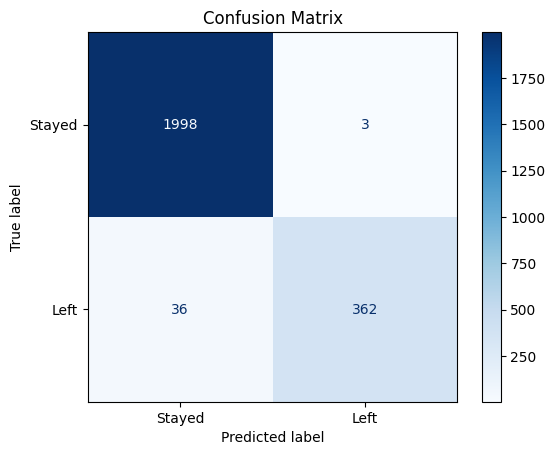

In [35]:
# Print Precision, Recall, F1-Score
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Display Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stayed', 'Left'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.savefig('images/confusion_matrix.png', bbox_inches='tight', dpi=100)
plt.show()

In [26]:
# Verify all columns are numeric
print(X.dtypes)

satisfaction_level        float64
last_evaluation           float64
number_project              int64
average_monthly_hours       int64
time_spent_company          int64
work_accident               int64
promotion_last_5years       int64
department_RandD             bool
department_accounting        bool
department_hr                bool
department_management        bool
department_marketing         bool
department_product_mng       bool
department_sales             bool
department_support           bool
department_technical         bool
salary_low                   bool
salary_medium                bool
dtype: object


In [27]:
# Check class proportions
print("Train target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True))

Train target distribution:
left
0    0.833924
1    0.166076
Name: proportion, dtype: float64

Test target distribution:
left
0    0.834098
1    0.165902
Name: proportion, dtype: float64


C:\Users\96659\AppData\Local\Temp\ipykernel_17544\3493325052.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp.head(10), x='Importance', y='Feature', palette='viridis')


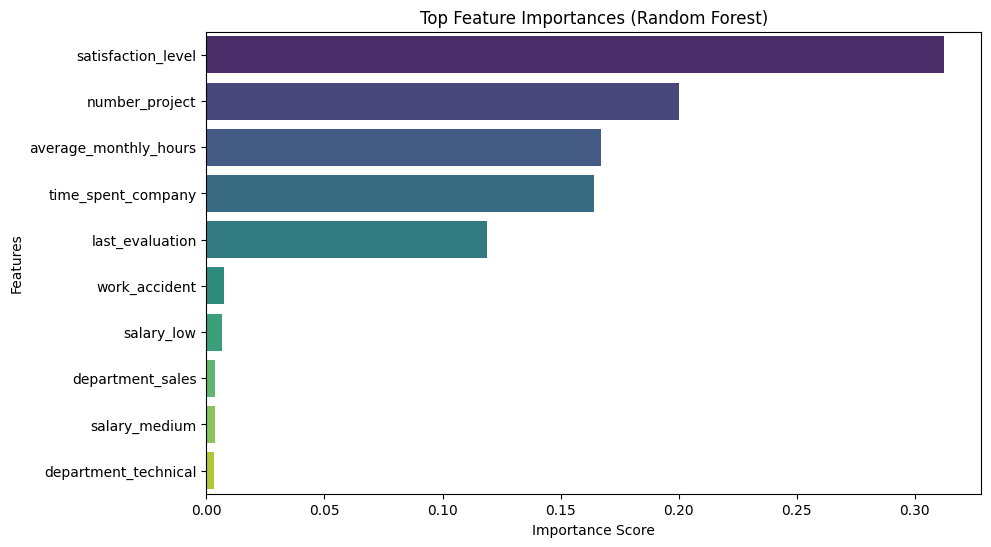

In [36]:
# Extract feature importances from the Random Forest model
importances = rf.feature_importances_
feature_names = X.columns

# Create and sort a DataFrame
feat_imp = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_imp = feat_imp.sort_values(by='Importance', ascending=False)

# Plot the top features
plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp.head(10), x='Importance', y='Feature', palette='viridis')
plt.title('Top Feature Importances (Random Forest)')
plt.xlabel('Importance Score')
plt.ylabel('Features')

plt.savefig('images/feature_importance.png', bbox_inches='tight', dpi=100)
plt.show()

In [29]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    rf,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy'
)

print("CV scores:", cv_scores)
print("Mean CV accuracy:", cv_scores.mean())

CV scores: [0.98436686 0.98228244 0.9822732  0.98540146 0.98383733]
Mean CV accuracy: 0.9836322576333151


# pacE: Execute Stage
- Interpret model performance and results
- Share actionable steps with stakeholders



### 1. What key insights emerged from your model(s)?

The model showed that **satisfaction level, number of projects, time spent at the company, and average monthly hours** were important factors in predicting employee turnover.

### 2. What business recommendations do you propose?

Salifort Motors should focus on **employee satisfaction, workload, and working hours** to help reduce employee turnover.

### 3. What recommendations would you make to your manager/company?

Use the model as an **early-warning tool** to identify employees who may be at risk of leaving and investigate their needs.

### 4. Could your model be improved?

Yes. It could be improved by **tuning the model, testing other algorithms, and using cross-validation** to make sure it performs well on new data.

### 5. What other questions could you address?

* What factors have the biggest impact on turnover?
* Does workload increase the chance of leaving?
* Which employee groups have the highest turnover?

### 6. What resources did you use?

* [Python Documentation](https://docs.python.org/3/?utm_source=chatgpt.com)
* [pandas Documentation](https://pandas.pydata.org/docs/?utm_source=chatgpt.com)
* [Scikit-learn Documentation](https://scikit-learn.org/stable/?utm_source=chatgpt.com)
* Google Advanced Data Analytics course materials.

### 7. Ethical considerations?

Employee data should be kept **private**, and model predictions should support decisions rather than automatically determine how employees are treated.


## Step 4. Results and Evaluation
- Interpret model
- Evaluate model performance using metrics
- Prepare results, visualizations, and actionable steps to share with stakeholders




### Summary of model results

The Random Forest model achieved a mean cross-validation accuracy of 98.36%. The similar scores across all five folds indicate that the model is stable and performs consistently on different subsets of the data. The model identified satisfaction level, number of projects, time spent at the company, and average monthly hours as the most important factors in predicting employee turnover. The model can help Salifort Motors identify employees at higher risk of leaving and better understand the factors related to turnover.

### Conclusion, Recommendations, Next Steps

The model indicates that employee satisfaction, workload, and time spent at the company are important factors associated with employee turnover. Based on these findings, Salifort Motors should focus on improving employee satisfaction, managing workloads, and monitoring working hours to help identify potential turnover risks. As a next step, the model could be used as an early-warning tool to support HR decision-making, while continuing to collect relevant employee data and regularly evaluating and updating the model to maintain its performance.